In [2]:
import math
import random
from typing import List, Tuple, Dict, Any
import numpy as np
from scipy.special import expit

Coord = Tuple[float, float] # (lat, lon) or generic 2D coordinates

# ==================== UTILITY FUNCTIONS ====================

def haversine(a: Coord, b: Coord) -> float:
 """Distancia Haversine en metros entre dos coords (lat,lon en grados)."""
 lat1, lon1 = math.radians(a[0]), math.radians(a[1])
 lat2, lon2 = math.radians(b[0]), math.radians(b[1])
 dlat = lat2 - lat1
 dlon = lon2 - lon1
 R = 6371000.0
 s = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
 return 2 * R * math.asin(math.sqrt(s))

def euclidean(a: Coord, b: Coord) -> float:
 """Distancia euclidiana (útil para espacios sintéticos)."""
 return math.hypot(a[0] - b[0], a[1] - b[1])

def weighted_choice(items: List, weights: List[float]):
 """Escoge un elemento de items con probabilidades proporcionales a weights."""
 total = sum(weights)
 if total == 0:
 return random.choice(items)
 probs = [w / total for w in weights]
 return random.choices(items, weights=probs, k=1)[0]

# ==================== DIFFERENTIAL PRIVACY MECHANISMS ====================

def exponential_mechanism(
 true_point: Coord,
 candidates: List[Coord],
 epsilon: float,
 dist_fn = haversine
) -> Coord:
 """
 Exponential Mechanism según ecuación del paper.
 u(p_alpha, p) = -dist(p_alpha, p)
 Sensibilidad Delta_u es la máxima diferencia de utilidad.
 """
 if not candidates:
 raise ValueError("No candidates available")
 
 # Calcular utilidades: u = -dist
 utilities = [-dist_fn(true_point, c) for c in candidates]
 
 # Sensibilidad = max_u - min_u (diferencia máxima de utilidades)
 delta_u = max(utilities) - min(utilities) if max(utilities) != min(utilities) else 1e-9
 
 # Probabilidades según EM: exp(epsilon * u / (2 * Delta_u))
 weights = [math.exp((epsilon * u) / (2 * delta_u)) for u in utilities]
 
 return weighted_choice(candidates, weights)

def compute_b_parameter(epsilon: float) -> float:
 """
 Calcula el parámetro b para Square-Wave mechanism
 usando una forma algebraicamente equivalente
 pero numéricamente estable (sin overflow).
 """
 if epsilon <= 0:
 return 0.0
 
 exp_neg = math.exp(-epsilon)
 exp_neg2 = exp_neg * exp_neg

 numerator = (epsilon - 1.0) * exp_neg + exp_neg2
 denominator = 2.0 * (1.0 - (1.0 + epsilon) * exp_neg)

 if abs(denominator) < 1e-15:
 return 0.0

 b = numerator / denominator
 return max(0.0, b)

def square_wave_mechanism(
 normalized_input: float, # r ∈ [0,1]
 epsilon: float,
 num_samples: int = 1000
) -> float:
 """
 Square-Wave mechanism discretizado.
 Input: r normalizado ∈ [0,1]
 Output: r̂ ∈ [-b, b+1]
 """
 b = compute_b_parameter(epsilon)
 output_range = (-b, b + 1)
 
 # Crear grid discreto del rango de salida
 candidates = np.linspace(output_range[0], output_range[1], num_samples)
 
 # Probabilidad relativa de los pesos, estable numéricamente
 p_big = expit(epsilon) # seguro ahora funciona
 p_small = 1 - p_big

 weights = []
 for candidate in candidates:
 if abs(normalized_input - candidate) <= b:
 weights.append(p_big)
 else:
 weights.append(p_small)
 
 return float(weighted_choice(list(candidates), weights))

# ==================== ATP CORE FUNCTIONS ====================

def calculate_anchor(trajectory: List[Coord]) -> Coord:
 """
 Calcula el anchor α según ecuación (9):
 lat(α) = Σlat(p_i)/|τ|, lon(α) = Σlon(p_i)/|τ|
 """
 if not trajectory:
 raise ValueError("Trajectory cannot be empty")
 
 n = len(trajectory)
 avg_lat = sum(p[0] for p in trajectory) / n
 avg_lon = sum(p[1] for p in trajectory) / n
 
 return (avg_lat, avg_lon)

def map_anchor_to_domain(anchor: Coord, domain_P: List[Coord], dist_fn) -> Coord:
 """
 Mapea el anchor α al punto más cercano en P: p_α = argmin_p dist(α, p)
 """
 if not domain_P:
 raise ValueError("Domain P cannot be empty")
 
 distances = [dist_fn(anchor, p) for p in domain_P]
 min_idx = int(np.argmin(distances))
 
 return domain_P[min_idx]

def calculate_max_radius(perturbed_anchor: Coord, trajectory: List[Coord], dist_fn) -> float:
 """
 Calcula R^τ_max = max_{p∈P^τ} dist(p̂_α, p)
 CORRECCIÓN: Debe usar la trayectoria original τ, no todo el dominio P
 """
 if not trajectory:
 return 0.0
 
 distances = [dist_fn(perturbed_anchor, p) for p in trajectory]
 return max(distances)

def calculate_delta_R(perturbed_anchor: Coord, domain_P: List[Coord], dist_fn) -> float:
 """
 Calcula ΔR = max_{p∈P} dist(p̂_α, p)
 """
 if not domain_P:
 return 1.0
 
 distances = [dist_fn(perturbed_anchor, p) for p in domain_P]
 max_dist = max(distances)
 
 return max_dist if max_dist > 0 else 1e-9

def calculate_calibration_center(
 perturbed_anchor: Coord,
 R_hat_tau_max: float,
 domain_P: List[Coord],
 epsilon: float,
 dist_fn
) -> float:
 """
 Calcula η (centro de calibración) según el algoritmo del paper,
 versión estable numéricamente para epsilon grande.
 """
 b = compute_b_parameter(epsilon)
 delta_R = calculate_delta_R(perturbed_anchor, domain_P, dist_fn)
 
 # Test values V = {0.0, 0.1, ..., 1.0}
 V = [0.1 * k for k in range(11)]
 
 # Calcular V_R
 target_normalized = (2 * b + 1) * R_hat_tau_max / delta_R - b
 V_R = [v_k for v_k in V if (v_k - b) <= target_normalized <= (v_k + b)]
 
 if not V_R:
 l = max(0.0, target_normalized - b)
 u = min(1.0, target_normalized + b)
 else:
 l, u = min(V_R), max(V_R)
 
 # Identificar P_R (puntos candidatos)
 P_R = [p for p in domain_P if l <= (2 * b + 1) * dist_fn(perturbed_anchor, p) / delta_R - b <= u]
 
 # Calcular q de manera estable
 exp_neg = math.exp(-epsilon)
 q = 1.0 / (2 * b + exp_neg) if (2 * b + exp_neg) != 0 else 0.5
 
 # Calcular η como promedio ponderado
 weighted_sum = sum(q * dist_fn(perturbed_anchor, p) for p in P_R)
 weighted_sum += sum((1 - q) * dist_fn(perturbed_anchor, p) for p in domain_P if p not in P_R)
 total_weight = q * len(P_R) + (1 - q) * (len(domain_P) - len(P_R))
 
 if total_weight == 0:
 return R_hat_tau_max
 
 return weighted_sum / total_weight


def calibrate_radius(
 R_hat_tau_max: float,
 eta: float,
 delta_R: float,
 epsilon: float
) -> float:
 """
 Calibra el radio según ecuaciones (10), (11), (12).
 R̂ = R̂^τ_max + ξe^(-ε)
 """
 # Calcular β según ecuación (12)
 if R_hat_tau_max <= eta:
 if eta == 0:
 beta = 0.0
 else:
 beta = (eta - R_hat_tau_max) / eta
 else:
 denominator = delta_R - eta
 if denominator == 0:
 beta = 0.0
 else:
 beta = (R_hat_tau_max - eta) / denominator
 
 # Calcular ξ según ecuación (11)
 sigmoid_term = 1 - math.exp(-beta / 2)
 if sigmoid_term == 0:
 xi = 0.0
 else:
 xi = (eta - R_hat_tau_max) / sigmoid_term
 
 # Aplicar calibración según ecuación (10)
 calibrated_radius = R_hat_tau_max + xi * math.exp(-epsilon)
 
 return max(0.0, calibrated_radius) # Asegurar no-negativo

def create_restricted_domain(
 perturbed_anchor: Coord,
 calibrated_radius: float,
 domain_P: List[Coord],
 dist_fn
) -> List[Coord]:
 """
 Crea P̂_α = {p ∈ P | dist(p̂_α, p) ≤ R̂}
 """
 restricted_domain = [
 p for p in domain_P 
 if dist_fn(perturbed_anchor, p) <= calibrated_radius
 ]
 
 # Fallback si el dominio queda vacío
 if not restricted_domain:
 restricted_domain = domain_P.copy()
 
 return restricted_domain

# ==================== MAIN ATP ALGORITHM ====================

def anchor_based_pivot_sampling(
 trajectory: List[Coord],
 domain_P: List[Coord],
 epsilon_anchor: float,
 epsilon_radius: float,
 epsilon_points: float,
 dist_fn = haversine,
 verbose: bool = False
) -> Dict[str, Any]:
 """
 Implementación completa del mecanismo ATP (Algorithm 4 y 5).
 
 Args:
 trajectory: Lista de coordenadas de la trayectoria τ
 domain_P: Dominio discreto de ubicaciones P
 epsilon_anchor: Budget de privacidad para perturbar anchor
 epsilon_radius: Budget para perturbar radio (SW mechanism)
 epsilon_points: Budget para perturbar puntos individuales
 dist_fn: Función de distancia
 verbose: Imprimir información intermedia
 
 Returns:
 Diccionario con resultados intermedios y trayectoria perturbada
 """
 # Validaciones
 if not trajectory:
 raise ValueError("Trajectory cannot be empty")
 if not domain_P:
 raise ValueError("Domain P cannot be empty")
 
 result = {}
 
 # Step 1: Calcular anchor α (Algorithm 5, Line 1)
 alpha = calculate_anchor(trajectory)
 result["alpha"] = alpha
 if verbose: print(f"Alpha: {alpha}")
 
 # Step 2: Mapear α a p_α ∈ P
 p_alpha = map_anchor_to_domain(alpha, domain_P, dist_fn)
 result["p_alpha"] = p_alpha
 if verbose: print(f"p_alpha: {p_alpha}")
 
 # Step 3: Perturbar p_α usando EM (Algorithm 5, Line 2)
 p_hat_alpha = exponential_mechanism(p_alpha, domain_P, epsilon_anchor, dist_fn)
 result["p_hat_alpha"] = p_hat_alpha
 if verbose: print(f"p_hat_alpha: {p_hat_alpha}")
 
 # Step 4: Calcular R^τ_max (Algorithm 5, Line 3 parte 1)
 R_tau_max = calculate_max_radius(p_hat_alpha, trajectory, dist_fn)
 result["R_tau_max"] = R_tau_max
 
 # Step 5: Calcular ΔR
 delta_R = calculate_delta_R(p_hat_alpha, domain_P, dist_fn)
 result["delta_R"] = delta_R
 
 # Step 6: Normalizar y aplicar SW mechanism (Algorithm 5, Line 3)
 r_normalized = R_tau_max / delta_R if delta_R > 0 else 0.0
 r_hat = square_wave_mechanism(r_normalized, epsilon_radius)
 result["r_normalized"] = r_normalized
 result["r_hat"] = r_hat
 
 # Mapear de vuelta al rango real
 b = compute_b_parameter(epsilon_radius)
 R_hat_tau_max = ((r_hat + b) * delta_R) / (2 * b + 1) if (2 * b + 1) > 0 else R_tau_max
 result["R_hat_tau_max"] = R_hat_tau_max
 
 # Step 7: Calcular centro de calibración η
 eta = calculate_calibration_center(p_hat_alpha, R_hat_tau_max, domain_P, epsilon_radius, dist_fn)
 result["eta"] = eta
 
 # Step 8: Calibrar radio (Algorithm 5, Line 4)
 calibrated_radius = calibrate_radius(R_hat_tau_max, eta, delta_R, epsilon_radius)
 result["calibrated_radius"] = calibrated_radius
 if verbose: print(f"Calibrated radius: {calibrated_radius}")
 
 # Step 9: Crear dominio restringido P̂_α (Algorithm 5, Line 5)
 restricted_domain = create_restricted_domain(p_hat_alpha, calibrated_radius, domain_P, dist_fn)
 result["restricted_domain"] = restricted_domain
 result["restricted_domain_size"] = len(restricted_domain)
 if verbose: print(f"Restricted domain size: {len(restricted_domain)}")
 
 # Step 10: Perturbar cada punto de la trayectoria (Algorithm 4, Lines 5-6)
 perturbed_trajectory = []
 for point in trajectory:
 perturbed_point = exponential_mechanism(point, restricted_domain, epsilon_points, dist_fn)
 perturbed_trajectory.append(perturbed_point)
 
 result["perturbed_trajectory"] = perturbed_trajectory
 
 return result

# ==================== EXAMPLE AND TESTING ====================

def create_synthetic_example():
 """Crea ejemplo sintético según la descripción del paper."""
 # Grilla 21x21 (coordenadas 1-21)
 domain_P = [(i, j) for i in range(1, 22) for j in range(1, 22)]
 
 # Excluir algunas ubicaciones "públicas" (opcional)
 excluded = [(3, 3), (8, 8), (15, 15)]
 domain_P = [p for p in domain_P if p not in excluded]
 
 # Trayectoria diagonal
 trajectory = [(i, i) for i in range(1, 21)]
 
 return trajectory, domain_P

def run_atp_example():
 """Ejecuta ejemplo completo de ATP."""
 trajectory, domain_P = create_synthetic_example()
 
 # Parámetros de privacidad
 epsilon_anchor = 2.0
 epsilon_radius = 2.0 
 epsilon_points = 2.0
 
 print("=== ATP Example ===")
 print(f"Trajectory length: {len(trajectory)}")
 print(f"Domain size: {len(domain_P)}")
 print(f"Privacy budgets: ε_anchor={epsilon_anchor}, ε_radius={epsilon_radius}, ε_points={epsilon_points}")
 print()
 
 # Ejecutar ATP
 result = anchor_based_pivot_sampling(
 trajectory=trajectory,
 domain_P=domain_P,
 epsilon_anchor=epsilon_anchor,
 epsilon_radius=epsilon_radius,
 epsilon_points=epsilon_points,
 dist_fn=euclidean,
 verbose=True
 )
 
 print("\n=== Results ===")
 print(f"Original anchor: {result['alpha']}")
 print(f"Mapped anchor: {result['p_alpha']}")
 print(f"Perturbed anchor: {result['p_hat_alpha']}")
 print(f"Max radius (original): {result['R_tau_max']:.2f}")
 print(f"Max radius (after SW): {result['R_hat_tau_max']:.2f}")
 print(f"Calibrated radius: {result['calibrated_radius']:.2f}")
 print(f"Restricted domain size: {result['restricted_domain_size']}")
 print(f"Perturbed trajectory (first 5 points): {result['perturbed_trajectory'][:5]}")
 
 return result

if __name__ == "__main__":
 # Set random seed for reproducibility

 result = run_atp_example()

=== ATP Example ===
Trajectory length: 20
Domain size: 438
Privacy budgets: ε_anchor=2.0, ε_radius=2.0, ε_points=2.0

Alpha: (10.5, 10.5)
p_alpha: (10, 10)
p_hat_alpha: (7, 10)
Calibrated radius: 10.164442275826595
Restricted domain size: 279

=== Results ===
Original anchor: (10.5, 10.5)
Mapped anchor: (10, 10)
Perturbed anchor: (7, 10)
Max radius (original): 16.40
Max radius (after SW): 6.15
Calibrated radius: 10.16
Restricted domain size: 279
Perturbed trajectory (first 5 points): [(14, 12), (6, 3), (7, 10), (6, 8), (5, 5)]


In [3]:
import itertools
import numpy as np
import math
from typing import List, Tuple, Dict
from collections import defaultdict
import matplotlib.pyplot as plt
from mpmath import *

# Definición de tipos
Point = Tuple[float, float]
Trajectory = List[Point]

class PivotSampling:
 def __init__(self, epsilon: float = 5.0, 
 D_candidates: List[int] = [2, 4, 6, 8, 12], R: float = 6371000.0): 
 self.epsilon_total = epsilon
 self.epsilon_dir = 0.75 * epsilon
 self.epsilon_ind = 0.125 * epsilon 
 self.epsilon_rest = 0.125 * epsilon 
 self.D_candidates = D_candidates
 self.R = R

 self.D_opt = self._select_optimal_granularity()
 
 def haversine_distance(self, p1: Point, p2: Point) -> float:
 """Distancia Haversine en metros"""
 lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
 lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
 
 dlat = lat2 - lat1
 dlon = lon2 - lon1
 
 a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
 return self.R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))


 def _select_optimal_granularity(self) -> int:
 """
 Selecciona la granularidad óptima |D| según la Ecuación 8 del paper.
 Esta implementación es 100% fiel a la fórmula y explicación del paper.
 
 CLAVE: El paper evalúa el performance promedio considerando que
 CUALQUIER dirección puede ser la correcta, no solo d=0.
 """
 best_score = -1
 best_g = 2
 
 # D_c: conjunto de granularidades candidatas
 D_c = self.D_candidates
 
 # Θ = {θⱼ | θⱼ = π/g, g ∈ D_c}
 Theta = [math.pi / g for g in D_c]
 
 # Para cada granularidad candidata g
 for g in D_c:
 
 # R(g) = {0, 1, 2, ..., g-1}
 R_g = list(range(g))
 
 # Calcular score promedio considerando TODAS las posibles direcciones correctas
 # Esto es lo que hace el paper: evaluar el performance general del mecanismo
 total_score_all_directions = 0.0
 
 # Para cada posible dirección correcta d
 for d_correct in R_g:
 score_for_this_d = 0.0
 
 # Sumar sobre todos los θⱼ ∈ Θ
 for theta_j in Theta:
 
 # Sumar sobre todos los dᵢ ∈ R(g)
 for d_i in R_g:
 # φ(dᵢ; θⱼ): proporción de intersección
 phi = self._calculate_phi(d_i, theta_j, g)
 
 # λ(dᵢ; ε; g): probabilidad k-RR con d_correct como dirección verdadera
 lambda_val = self._calculate_lambda(d_i, d_correct, g)
 
 score_for_this_d += phi * lambda_val
 
 # Promedio sobre |Θ| para esta dirección correcta específica
 avg_score_for_this_d = score_for_this_d / len(Theta)
 total_score_all_directions += avg_score_for_this_d
 
 # Promedio sobre todas las posibles direcciones correctas
 # Esto representa el performance esperado del mecanismo en general
 overall_avg_score = total_score_all_directions / len(R_g)
 
 if overall_avg_score > best_score:
 best_score = overall_avg_score
 best_g = g
 
 return best_g

 def _calculate_phi(self, d_i: int, theta_j: float, g: int) -> float:
 """
 Calcula φ(dᵢ; θⱼ) = |[(2dᵢ-1)π/g, (2dᵢ+1)π/g] ∩ [-θⱼ, θⱼ]| / (2π/g)
 
 Exactamente como en el paper.
 """
 # Límites del sector dᵢ
 sector_min = (2 * d_i - 1) * math.pi / g
 sector_max = (2 * d_i + 1) * math.pi / g
 
 # Límites del rango de consulta (centrado en 0)
 query_min = -theta_j
 query_max = theta_j
 
 # Calcular intersección
 intersect_min = max(sector_min, query_min)
 intersect_max = min(sector_max, query_max)
 
 # Si no hay intersección
 if intersect_min >= intersect_max:
 return 0.0
 
 # Longitud de la intersección
 intersect_length = intersect_max - intersect_min
 
 # Longitud del sector
 sector_length = 2 * math.pi / g
 
 # Proporción
 return intersect_length / sector_length

 def _calculate_lambda(self, d_i: int, d_correct: int, g: int) -> float:
 """
 Calcula λ(dᵢ; ε; g) según k-RR, estable numéricamente.
 """
 epsilon = self.epsilon_dir

 # Caso extremo para epsilon muy grande
 if epsilon > 50:
 return 1.0 if d_i == d_correct else 0.0

 # Probabilidad estable: P(correcta) = e^ε / (e^ε + g - 1)
 # P(incorrecta) = 1 / (e^ε + g - 1)
 exp_neg = math.exp(-epsilon) # ahora es estable para epsilon grande
 if d_i == d_correct:
 return 1.0 / (1.0 + (g - 1) * exp_neg)
 else:
 return exp_neg / (1.0 + (g - 1) * exp_neg)


 
 def exponential_mechanism(self, p: Point, P: List[Point]) -> Point:
 """
 Aplica el Mecanismo Exponencial para seleccionar un punto perturbado.
 Protege contra overflow/underflow y valores extremadamente pequeños.
 """
 if not P:
 return p # Si no hay puntos en el dominio, devolver el original

 # Calcular utilidades
 utilities = np.array([-self.haversine_distance(p, r) for r in P])
 delta_u = np.max(utilities) - np.min(utilities)

 if delta_u == 0:
 return P[np.random.randint(len(P))]

 # Ajuste numérico: restar el máximo para evitar overflow/underflow
 scaled_utilities = (self.epsilon_ind * utilities) / (2 * delta_u)
 max_u = np.max(scaled_utilities)
 weights = np.exp(scaled_utilities - max_u)

 # Valores extremadamente pequeños se ponen a 0
 weights[weights < 1e-300] = 0

 # Normalizar probabilidades
 total_weight = np.sum(weights)
 if total_weight == 0:
 # Todos eran demasiado pequeños; elegir aleatoriamente
 probs = np.ones(len(P)) / len(P)
 else:
 probs = weights / total_weight

 # Seleccionar un índice según las probabilidades
 selected_idx = np.random.choice(len(P), p=probs)
 return P[selected_idx]

 
 def kRR_mechanism(self, d: int) -> int:
 D = self.D_opt
 if d < 0 or d >= D:
 raise ValueError(f"Direction {d} is out of bounds for D={D}")

 # Estabilidad numérica usando e^{-epsilon}
 # # Fórmula original: correct_prob = e^ε / ((D-1)+e^ε)
 # Esto puede causar overflow si ε es grande (e^ε → ∞).
 # Reescribimos la fórmula:
 # correct_prob = 1 / (1 + (D-1)*e^{-ε})
 # Así evitamos calcular e^ε y solo calculamos e^{-ε}, que es seguro.
 correct_prob = 1.0 / (1.0 + (D - 1) * math.exp(-self.epsilon_dir))
 incorrect_prob = (1.0 - correct_prob) / (D - 1)

 probs = [incorrect_prob] * D
 probs[d] = correct_prob

 return np.random.choice(D, p=probs)


 
 def get_direction(self, pivot, point) -> int:
 """
 Calcula la dirección discreta de 'point' relativa a 'pivot'
 siguiendo exactamente la definición del paper.
 """
 # Extraer coordenadas (asumiendo formato [lat, lon])
 pivot_lat, pivot_lon = pivot[0], pivot[1]
 point_lat, point_lon = point[0], point[1]
 
 # Convertir a radianes
 pivot_lat_rad = math.radians(pivot_lat)
 pivot_lon_rad = math.radians(pivot_lon)
 point_lat_rad = math.radians(point_lat)
 point_lon_rad = math.radians(point_lon)
 
 # Calcular diferencia de longitud
 delta_lon = point_lon_rad - pivot_lon_rad
 
 # Fórmula de bearing para coordenadas geográficas
 y = math.sin(delta_lon) * math.cos(point_lat_rad)
 x = (math.cos(pivot_lat_rad) * math.sin(point_lat_rad) - 
 math.sin(pivot_lat_rad) * math.cos(point_lat_rad) * math.cos(delta_lon))
 
 # Calcular el ángulo (bearing)
 theta = math.atan2(y, x)
 
 # El paper define los intervalos como [(2d-1)π/D, (2d+1)π/D]
 # Necesitamos encontrar qué d contiene nuestro theta
 
 for d in range(self.D_opt):
 interval_start = (2 * d - 1) * math.pi / self.D_opt
 interval_end = (2 * d + 1) * math.pi / self.D_opt
 
 # Manejar el caso donde el intervalo cruza -π/π
 if interval_start < -math.pi:
 # Intervalo se extiende más allá de -π
 if theta >= interval_start + 2*math.pi or theta <= interval_end:
 return d
 elif interval_end > math.pi:
 # Intervalo se extiende más allá de π
 if theta >= interval_start or theta <= interval_end - 2*math.pi:
 return d
 else:
 # Intervalo normal
 if interval_start <= theta <= interval_end:
 return d
 
 # Fallback (no debería ocurrir si los intervalos cubren todo el círculo)
 return 0
 
 def calculate_bearing(self, pivot: Point, point: Point) -> float:
 """
 Calcula el bearing geográfico de point relativo a pivot.
 Retorna el ángulo en radianes [-π, π].
 """
 # Extraer coordenadas (formato [lat, lon])
 pivot_lat, pivot_lon = pivot[0], pivot[1]
 point_lat, point_lon = point[0], point[1]
 
 # Convertir a radianes
 pivot_lat_rad = math.radians(pivot_lat)
 pivot_lon_rad = math.radians(pivot_lon)
 point_lat_rad = math.radians(point_lat)
 point_lon_rad = math.radians(point_lon)
 
 # Calcular diferencia de longitud
 delta_lon = point_lon_rad - pivot_lon_rad
 
 # Fórmula de bearing para coordenadas geográficas
 y = math.sin(delta_lon) * math.cos(point_lat_rad)
 x = (math.cos(pivot_lat_rad) * math.sin(point_lat_rad) - 
 math.sin(pivot_lat_rad) * math.cos(point_lat_rad) * math.cos(delta_lon))
 
 return math.atan2(y, x)
 
 def point_in_sector(self, theta: float, d: int) -> bool:
 """
 Verifica si un ángulo theta está en el sector d.
 Maneja correctamente intervalos que cruzan límites ±π.
 """
 theta_min = (2 * d - 1) * math.pi / self.D_opt
 theta_max = (2 * d + 1) * math.pi / self.D_opt
 
 # Caso 1: Intervalo normal (no cruza límites)
 if theta_min >= -math.pi and theta_max <= math.pi:
 return theta_min <= theta <= theta_max
 
 # Caso 2: Intervalo se extiende más allá de -π
 elif theta_min < -math.pi:
 # El intervalo se envuelve: [-π, theta_max] ∪ [theta_min + 2π, π]
 return (theta <= theta_max) or (theta >= theta_min + 2 * math.pi)
 
 # Caso 3: Intervalo se extiende más allá de π
 elif theta_max > math.pi:
 # El intervalo se envuelve: [-π, theta_max - 2π] ∪ [theta_min, π]
 return (theta >= theta_min) or (theta <= theta_max - 2 * math.pi)
 
 # Fallback (no debería ocurrir)
 return False
 
 def get_point_set(self, pivot: Point, d: int, P: List[Point]) -> List[Point]:
 """
 Obtiene el conjunto de puntos en P que caen en la dirección d relativa al pivot.
 Implementación correcta según el paper.
 """
 valid_points = []
 
 for point in P:
 # Calcular el bearing usando coordenadas geográficas
 theta = self.calculate_bearing(pivot, point)
 
 # Verificar si el punto está en el sector d
 if self.point_in_sector(theta, d):
 valid_points.append(point)
 
 return valid_points
 
 def get_sector_bounds(self, d: int) -> Tuple[float, float]:
 """
 Función auxiliar para obtener los límites de un sector.
 """
 theta_min = (2 * d - 1) * math.pi / self.D_opt
 theta_max = (2 * d + 1) * math.pi / self.D_opt
 return (theta_min, theta_max)
 
 def perturb_trajectory(self, tau: Trajectory, P: List[Point]) -> Trajectory:
 """
 Aplica el algoritmo Pivot Sampling completo a una trayectoria.
 """
 if not tau:
 return []
 
 tau_prime = self._perturb_trajectory_version(tau, P, even_pivots=True)
 tau_star = self._perturb_trajectory_version(tau, P, even_pivots=False)
 
 return self._combine_trajectories(tau, tau_prime, tau_star, P)
 
 def _perturb_trajectory_version(self, tau: Trajectory, P: List[Point], 
 even_pivots: bool) -> Trajectory:
 """
 Perturba una versión de la trayectoria (pivotes pares o impares).
 """
 n = len(tau)
 perturbed_tau = [None] * n
 
 # Primero perturbar todos los puntos pivote
 for i in range(n):
 if (even_pivots and i % 2 == 0) or (not even_pivots and i % 2 == 1):
 perturbed_tau[i] = self.exponential_mechanism(tau[i], P)
 
 # Luego perturbar los puntos no pivote
 for i in range(n):
 if perturbed_tau[i] is not None:
 continue
 
 # Encontrar pivotes vecinos
 prev_pivot = next_pivot = None
 prev_pivot_idx = next_pivot_idx = -1
 
 # Buscar pivote anterior
 for j in range(i-1, -1, -1):
 if perturbed_tau[j] is not None:
 prev_pivot = perturbed_tau[j]
 prev_pivot_idx = j
 break
 
 # Buscar pivote siguiente
 for j in range(i+1, n):
 if perturbed_tau[j] is not None:
 next_pivot = perturbed_tau[j]
 next_pivot_idx = j
 break
 
 # Determinar dominio de perturbación
 if prev_pivot and next_pivot:
 d_prev = self.get_direction(tau[prev_pivot_idx], tau[i]) # pivot como origen
 d_prev_pert = self.kRR_mechanism(d_prev)
 
 d_next = self.get_direction(tau[i], tau[next_pivot_idx])
 d_next_pert = self.kRR_mechanism(d_next)
 
 P_prev = self.get_point_set(prev_pivot, d_prev_pert, P)
 P_next = self.get_point_set(next_pivot, d_next_pert, P)
 
 P_j = list(set(P_prev) & set(P_next))
 
 if not P_j:
 P_j = list(set(P_prev) | set(P_next))
 elif prev_pivot:
 d_prev = self.get_direction(tau[prev_pivot_idx], tau[i]) # pivot como origen
 d_prev_pert = self.kRR_mechanism(d_prev)
 P_j = self.get_point_set(prev_pivot, d_prev_pert, P)
 elif next_pivot:
 d_next = self.get_direction(tau[i], tau[next_pivot_idx])
 d_next_pert = self.kRR_mechanism(d_next)
 P_j = self.get_point_set(next_pivot, d_next_pert, P)
 else:
 P_j = P
 
 perturbed_tau[i] = self.exponential_mechanism(tau[i], P_j)
 
 return perturbed_tau
 def _combine_trajectories(self, tau: Trajectory, tau_prime: Trajectory,
 tau_star: Trajectory, P: List[Point]) -> Trajectory:
 """
 Aproximación greedy: optimiza cada punto independientemente.
 Más eficiente pero no garantiza el óptimo global.
 """
 n = len(tau)
 final_tau = []
 
 for i in range(n):
 min_cost = float('inf')
 best_p = tau_prime[i] # Fallback
 
 # Buscar el mejor candidato para la posición i
 for candidate in P:
 cost = (self.haversine_distance(candidate, tau_prime[i]) + 
 self.haversine_distance(candidate, tau_star[i]))
 
 if cost < min_cost:
 min_cost = cost
 best_p = candidate
 
 final_tau.append(best_p)
 
 return final_tau
 
 def visualize_trajectories(self, original: Trajectory, perturbed: Trajectory):
 """
 Visualiza la trayectoria original y la perturbada.
 """
 orig_x, orig_y = zip(*original)
 pert_x, pert_y = zip(*perturbed)
 
 plt.figure(figsize=(10, 6))
 plt.plot(orig_x, orig_y, 'b-o', label='Original', linewidth=2)
 plt.plot(pert_x, pert_y, 'r--s', label='Perturbada', linewidth=2)
 
 for (ox, oy), (px, py) in zip(original, perturbed):
 plt.plot([ox, px], [oy, py], 'g-', alpha=0.3)
 
 plt.xlabel('Coordenada X')
 plt.ylabel('Coordenada Y')
 plt.title('Comparación de Trayectorias - Pivot Sampling')
 plt.legend()
 plt.grid(True)
 plt.show()
 
 total_dist = 0.0
 for (ox, oy), (px, py) in zip(original, perturbed):
 total_dist += math.sqrt((ox - px)**2 + (oy - py)**2)
 
 avg_dist = total_dist / len(original)
 print(f"Distancia promedio de perturbación: {avg_dist:.2f} unidades")

def cargar_trayectoria_real(ruta_archivo: str) -> Trajectory:
 """Carga trayectoria desde archivo PLT de GeoLife"""
 latlons = []
 with open(ruta_archivo, "r", encoding="utf-8", errors="ignore") as f:
 for i, linea in enumerate(f):
 if i < 6: continue # Saltar cabecera
 partes = linea.strip().split(",")
 try:
 latlons.append((float(partes[0]), float(partes[1])))
 except (ValueError, IndexError):
 continue
 return latlons

def crear_dominio_espacial(trayectoria: Trajectory, radio: float = 100.0) -> List[Point]:
 """Crea dominio alrededor de la trayectoria con resolución de ~10m"""
 lats = [p[0] for p in trayectoria]
 lons = [p[1] for p in trayectoria]
 
 lat_min, lat_max = min(lats), max(lats)
 lon_min, lon_max = min(lons), max(lons)
 
 # Convertir radio a grados aproximados (simplificación)
 delta_lat = (radio / 6371000.0) * (180 / math.pi)
 delta_lon = delta_lat / math.cos(math.radians((lat_min + lat_max)/2))
 
 # Crear rejilla
 grid_lats = np.linspace(lat_min - delta_lat, lat_max + delta_lat, 50)
 grid_lons = np.linspace(lon_min - delta_lon, lon_max + delta_lon, 50)
 
 return [(lat, lon) for lat in grid_lats for lon in grid_lons]


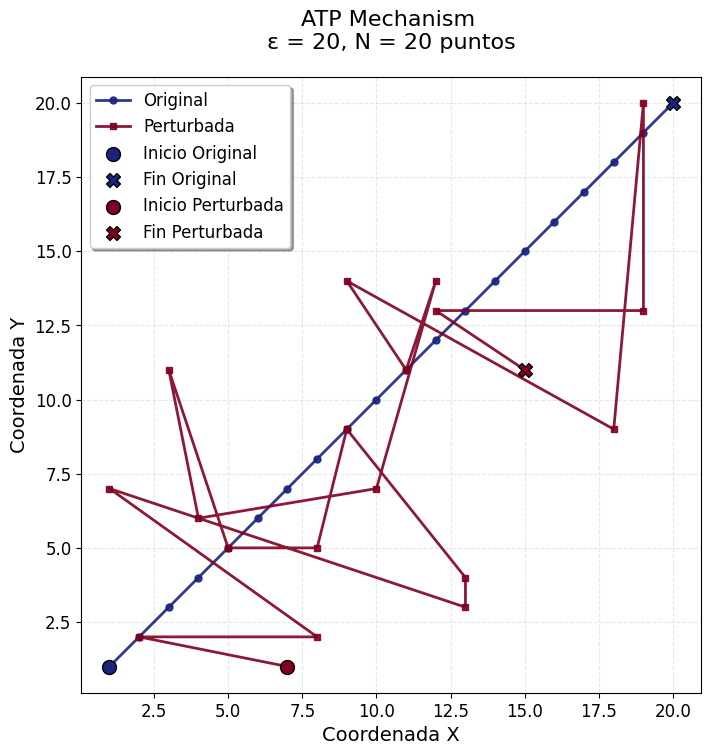

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ==================== OBTENER DATOS DEL ATP ====================
trajectory, domain_P = create_synthetic_example()

# Epsilon global
epsilon_global = 10.0

result = anchor_based_pivot_sampling(
 trajectory=trajectory,
 domain_P=domain_P,
 epsilon_anchor=epsilon_global,
 epsilon_radius=epsilon_global,
 epsilon_points=epsilon_global,
 dist_fn=euclidean,
 verbose=False
)

original_np = np.array(trajectory)
perturbed_np = np.array(result["perturbed_trajectory"])

# ==================== CONFIGURACIÓN DE ESTILO ====================
plt.rcParams.update({
 "figure.figsize": (8, 8),
 "axes.titlesize": 16,
 "axes.labelsize": 14,
 "xtick.labelsize": 12,
 "ytick.labelsize": 12,
 "legend.fontsize": 12,
 "lines.linewidth": 2,
 "axes.grid": True,
 "grid.alpha": 0.3,
 "grid.linestyle": "--"
})

fig, ax = plt.subplots()

color_original = "#1a237e" # Azul rey
color_perturbada = "#800020" # Vino

# ==================== GRAFICAR ====================
# Trayectoria original
ax.plot(original_np[:, 0], original_np[:, 1],
 color=color_original, marker="o", markersize=5, label="Original", alpha=0.9)

# Trayectoria perturbada
ax.plot(perturbed_np[:, 0], perturbed_np[:, 1],
 color=color_perturbada, marker="s", markersize=5, label="Perturbada", alpha=0.9)

# Inicio y fin
ax.scatter(*original_np[0], color=color_original, s=100, edgecolor="k", label="Inicio Original", zorder=5)
ax.scatter(*original_np[-1], color=color_original, s=100, edgecolor="k", marker="X", label="Fin Original", zorder=5)
ax.scatter(*perturbed_np[0], color=color_perturbada, s=100, edgecolor="k", label="Inicio Perturbada", zorder=5)
ax.scatter(*perturbed_np[-1], color=color_perturbada, s=100, edgecolor="k", marker="X", label="Fin Perturbada", zorder=5)

# Título con ε global y número de puntos
ax.set_title(f"ATP Mechanism \nε = 20, N = {len(original_np)} puntos", pad=20)

# Etiquetas
ax.set_xlabel("Coordenada X")
ax.set_ylabel("Coordenada Y")

# Ejes iguales y cuadrícula
ax.axis("equal")
ax.grid(True, linestyle="--", alpha=0.3)

# Leyenda con sombra
ax.legend(loc="best", frameon=True, shadow=True)

plt.show()


In [ ]:
import folium
from folium import plugins

ruta_archivo = "../data/raw/geolife_trajectories_1_3/Data/001/Trajectory/20081023055305.plt"
tau = cargar_trayectoria_real(ruta_archivo)
 
 
 
# Crear dominio alrededor de la trayectoria (100m de margen) ../data/raw/geolife_trajectories_1_3/Data/001\Trajectory\20081023055305.plt
P = crear_dominio_espacial(tau, radio=10.0)

# Usamos distancia euclidiana para este espacio sintético
global DIST
DIST = euclidean

# parámetros
eps_anchor = len(tau)*5
eps_radius = len(tau)*5
eps_points = len(tau)*5

result = anchor_based_pivot_sampling(tau, P, eps_anchor, eps_radius, eps_points, dist_fn=euclidean)


domain = result["perturbed_trajectory"] 
original_trajectory=tau
# Inicializar algoritmo con radio de 20m
ps = PivotSampling(epsilon=len(tau)*5)

# Aplicar perturbación
perturbed_trajectory = ps.perturb_trajectory(original_trajectory, domain)

# Crear un mapa centrado en el primer punto de la trayectoria original
map_center = original_trajectory[0]
m = folium.Map(location=map_center, zoom_start=16)

# Agregar la trayectoria original (azul)
folium.PolyLine(
 locations=original_trajectory,
 color='blue',
 weight=3,
 opacity=0.7,
 tooltip='Original'
).add_to(m)

# Agregar la trayectoria perturbada (rojo)
folium.PolyLine(
 locations=perturbed_trajectory,
 color='red',
 weight=3,
 opacity=0.7,
 tooltip='Perturbada'
).add_to(m)

# Conectar puntos originales con perturbados (verde con poca opacidad)
for orig, pert in zip(original_trajectory, perturbed_trajectory):
 folium.PolyLine(
 locations=[orig, pert],
 color='green',
 weight=1,
 opacity=0.3
 ).add_to(m)

# Agregar marcadores opcionales
folium.Marker(location=original_trajectory[0], popup="Inicio Original", icon=folium.Icon(color='blue')).add_to(m)
folium.Marker(location=perturbed_trajectory[0], popup="Inicio Perturbada", icon=folium.Icon(color='red')).add_to(m)

# Mostrar mapa
m.save("../artifacts/anchor/maps/trayectoria_anchor_mapa.html")

In [16]:
import time
import math
import numpy as np
import pandas as pd
from typing import List, Tuple
from scipy.spatial.distance import directed_hausdorff

# ---- TIPOS ----
Point = Tuple[float, float]
Trajectory = List[Point]

# ---- MÉTRICAS ----
def haversine_distance(p1: Point, p2: Point) -> float:
 R = 6371000.0
 lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
 lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
 dlat = lat2 - lat1
 dlon = lon2 - lon1
 a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
 return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

def trajectory_length(traj: Trajectory) -> float:
 return sum(haversine_distance(traj[i], traj[i+1]) for i in range(len(traj)-1))

def mean_displacement(original: Trajectory, perturbed: Trajectory) -> float:
 return np.mean([haversine_distance(o, p) for o, p in zip(original, perturbed)])

def max_displacement(original: Trajectory, perturbed: Trajectory) -> float:
 return np.max([haversine_distance(o, p) for o, p in zip(original, perturbed)])

def std_displacement(original: Trajectory, perturbed: Trajectory) -> float:
 return np.std([haversine_distance(o, p) for o, p in zip(original, perturbed)])

def trajectory_length_error(original: Trajectory, perturbed: Trajectory) -> float:
 return abs(trajectory_length(original) - trajectory_length(perturbed))

def mean_direction_error(original: Trajectory, perturbed: Trajectory) -> float:
 def bearing(p1: Point, p2: Point) -> float:
 lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
 lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
 dlon = lon2 - lon1
 y = math.sin(dlon) * math.cos(lat2)
 x = math.cos(lat1)*math.sin(lat2) - math.sin(lat1)*math.cos(lat2)*math.cos(dlon)
 return math.atan2(y, x)
 
 errors = []
 for i in range(len(original)-1):
 theta_orig = bearing(original[i], original[i+1])
 theta_pert = bearing(perturbed[i], perturbed[i+1])
 errors.append(abs(theta_orig - theta_pert))
 return np.mean(errors)

def hausdorff_distance(original: Trajectory, perturbed: Trajectory) -> float:
 a = np.array(original)
 b = np.array(perturbed)
 return max(directed_hausdorff(a, b)[0], directed_hausdorff(b, a)[0])

# ---- EVALUADOR ----
def evaluate_method(method_name: str, original: Trajectory, perturbed: Trajectory, runtime: float, epsilon: float) -> dict:
 return {
 "Método": method_name,
 "Tamaño Trayectoria": len(original),
 "Epsilon": epsilon,
 "Distancia Media (m)": mean_displacement(original, perturbed),
 "Distancia Máx (m)": max_displacement(original, perturbed),
 "Desv. Estándar (m)": std_displacement(original, perturbed),
 "Error Longitud (m)": trajectory_length_error(original, perturbed),
 "Error Dirección (rad)": mean_direction_error(original, perturbed),
 "Hausdorff (m)": hausdorff_distance(original, perturbed),
 "Tiempo (s)": runtime
 }
def get_selected_indices(traj_length: int) -> List[int]:
 step = traj_length // 5 # tamaño de cada tramo
 indices = []
 
 for i in range(1, 6): # 1 a 5 (porque no queremos incluir 0)
 end_point = i * step
 if end_point <= traj_length:
 indices.append(end_point)
 
 mid_point = (i * step) - (step // 2)
 if mid_point > 0 and mid_point < traj_length:
 indices.append(mid_point)
 
 return sorted(set(indices))

# ---- CARGAR DATOS ----
ruta_archivo = "../data/raw/geolife_trajectories_1_3/Data/000/Trajectory/20081023025304.plt"
original_trajectory = cargar_trayectoria_real(ruta_archivo)
domain = crear_dominio_espacial(original_trajectory, radio=100.0)

# ---- EJECUTAR PRUEBAS (10 corridas por epsilon) ----
max_epsilon = 5 * len(original_trajectory)
epsilons = get_selected_indices(len(original_trajectory)*5)
results = []
N_RUNS = 10

for epsilon in epsilons:
 for run in range(N_RUNS):
 # Crear dominio alrededor de la trayectoria (100m de margen) ../data/raw/geolife_trajectories_1_3/Data/001\Trajectory\20081023055305.plt
 tau=original_trajectory
 P = crear_dominio_espacial(tau, radio=10.0)

 # Usamos distancia euclidiana para este espacio sintético
 global DIST
 DIST = euclidean

 # parámetros
 eps_anchor = epsilon
 eps_radius = epsilon
 eps_points = epsilon

 result = anchor_based_pivot_sampling(tau, P, eps_anchor, eps_radius, eps_points, dist_fn=euclidean)


 domain = result["perturbed_trajectory"] 
 
 # Inicializar algoritmo con radio de 20m
 ps = PivotSampling(epsilon=epsilon)

 start_time = time.time()
 perturbed_trajectory = ps.perturb_trajectory(original_trajectory, domain)
 runtime = time.time() - start_time
 
 result = evaluate_method("AnchorSampling", original_trajectory, perturbed_trajectory, runtime, epsilon)
 result["Run"] = run # número de corrida
 results.append(result)


# ---- GUARDAR RESULTADOS ----
df_results = pd.DataFrame(results)
print(df_results)

df_results.to_csv("../artifacts/anchor/analysis_outputs/anchor_summary_metrics.csv", index=False)


 Método Tamaño Trayectoria Epsilon Distancia Media (m) \
0 AnchorSampling 908 454 874.123927 
1 AnchorSampling 908 454 165.235150 
2 AnchorSampling 908 454 599.585386 
3 AnchorSampling 908 454 106.517290 
4 AnchorSampling 908 454 611.371200 
.. ... ... ... ... 
95 AnchorSampling 908 4540 45.906134 
96 AnchorSampling 908 4540 711.326260 
97 AnchorSampling 908 4540 1102.010740 
98 AnchorSampling 908 4540 165.478361 
99 AnchorSampling 908 4540 39.553827 

 Distancia Máx (m) Desv. Estándar (m) Error Longitud (m) \
0 2270.630064 386.103851 26971.127647 
1 1637.704722 185.856673 107062.739462 
2 2084.291382 385.107310 60187.937905 
3 754.826864 98.107319 101780.471447 
4 2084.291382 391.148343 81782.317918 
.. ... ... ... 
95 818.474687 73.581690 14760.301095 
96 2061.406870 390.140008 4518.135656 
97 2404.314162 387.301711 10309.594704 
98 1544.150916 261.221704 18451.322551 
99 801.583619 65.584142 16058.896514 

 Error Dirección (rad) Hausdorff (m) Tiempo (s) Run 
0 1.403979 0.026633 5.06


 Gráfica de Distancia Media (m)
Descripción: Promedio de la distancia entre trayectorias originales y aproximadas.



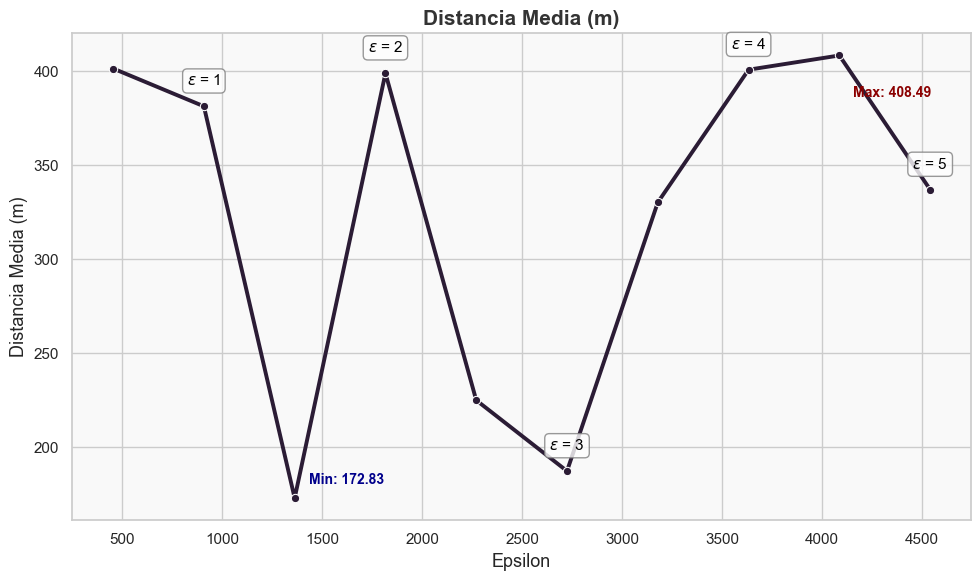


 Gráfica de Distancia Máx (m)
Descripción: Mayor distancia registrada entre dos trayectorias.



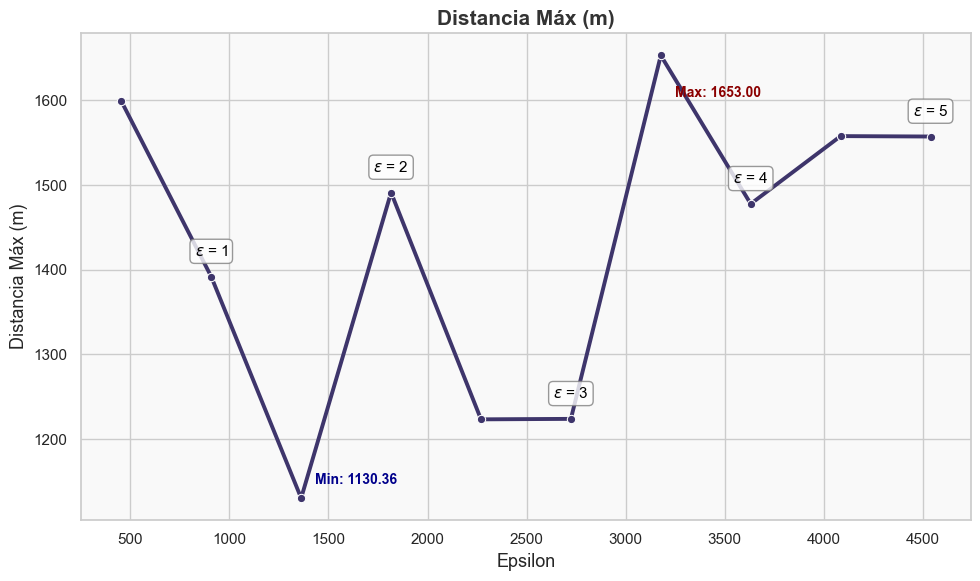


 Gráfica de Desv. Estándar (m)
Descripción: Variabilidad de la distancia entre las trayectorias.



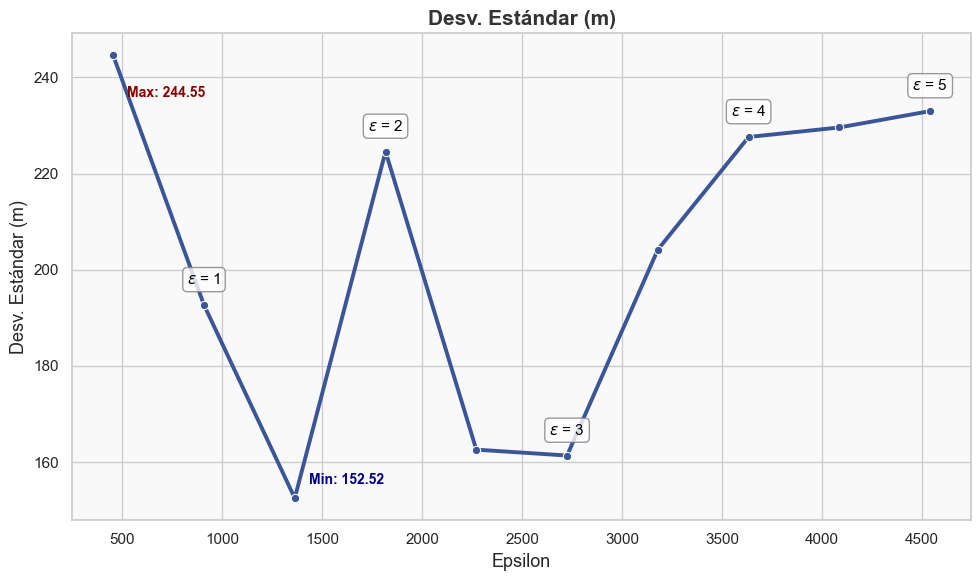


 Gráfica de Error Longitud (m)
Descripción: Diferencia en longitud total entre las trayectorias.



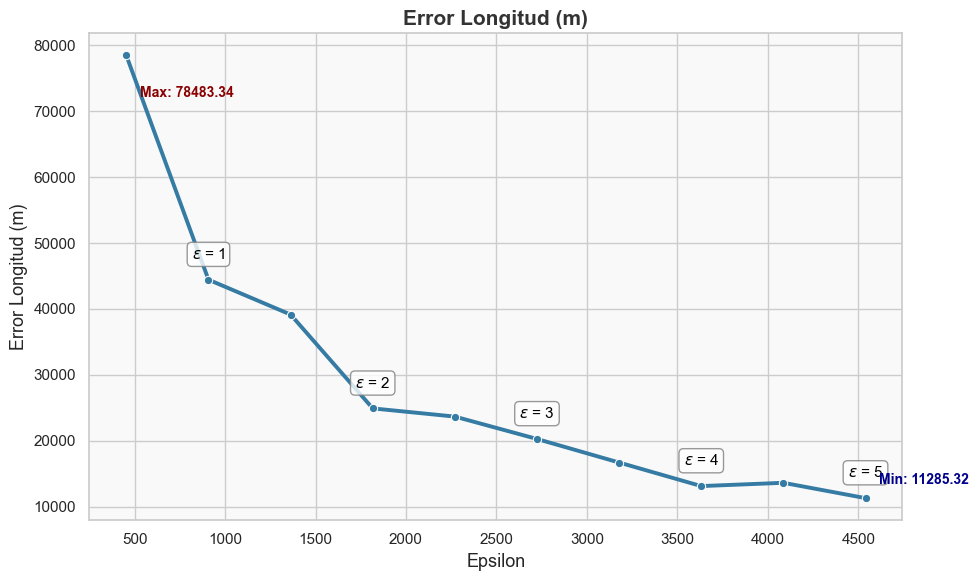


 Gráfica de Error Dirección (rad)
Descripción: Diferencia en orientación promedio entre las trayectorias.



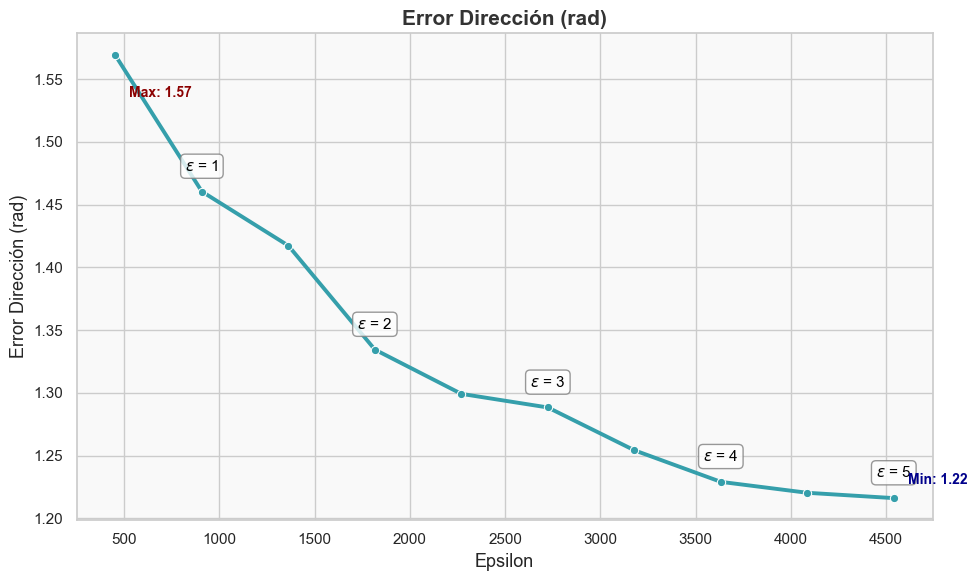


 Gráfica de Hausdorff (m)
Descripción: Distancia Hausdorff que mide la similitud entre trayectorias.



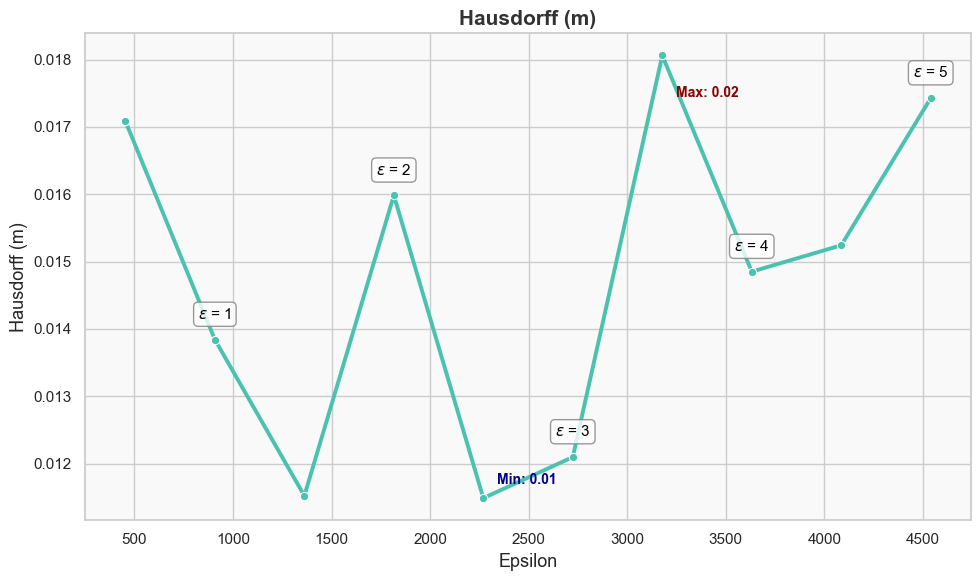


 Gráfica de Tiempo (s)
Descripción: Tiempo requerido para el procesamiento.



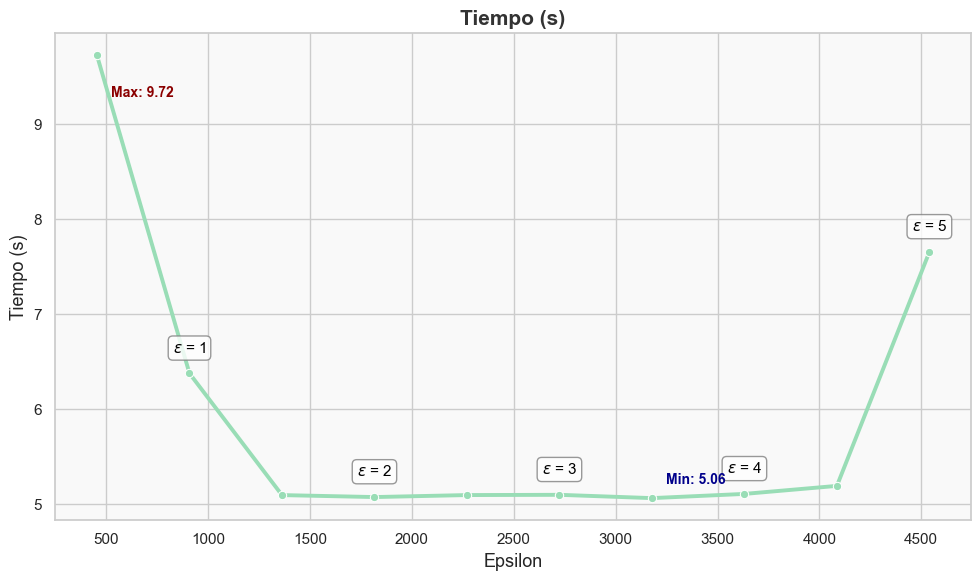

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leer datos
df = pd.read_csv("../artifacts/anchor/analysis_outputs/anchor_summary_metrics.csv")

# Agrupar por epsilon y promediar todas las métricas
df_avg = df.groupby("Epsilon", as_index=False).mean(numeric_only=True)

metricas = [
 "Distancia Media (m)",
 "Distancia Máx (m)",
 "Desv. Estándar (m)",
 "Error Longitud (m)",
 "Error Dirección (rad)",
 "Hausdorff (m)",
 "Tiempo (s)"
]

# Descripciones para cada métrica
descripciones = {
 "Distancia Media (m)": "Promedio de la distancia entre trayectorias originales y aproximadas.",
 "Distancia Máx (m)": "Mayor distancia registrada entre dos trayectorias.",
 "Desv. Estándar (m)": "Variabilidad de la distancia entre las trayectorias.",
 "Error Longitud (m)": "Diferencia en longitud total entre las trayectorias.",
 "Error Dirección (rad)": "Diferencia en orientación promedio entre las trayectorias.",
 "Hausdorff (m)": "Distancia Hausdorff que mide la similitud entre trayectorias.",
 "Tiempo (s)": "Tiempo requerido para el procesamiento."
}

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 13})

palette = sns.color_palette("mako", len(metricas))

# Índices y etiquetas para epsilon
annot_indices = [1, 3, 5, 7, 9]
epsilons_labels = [r'$\epsilon$ = 1', r'$\epsilon$ = 2', r'$\epsilon$ = 3', r'$\epsilon$ = 4', r'$\epsilon$ = 5']

for i, metrica in enumerate(metricas):
 print(f"\n Gráfica de {metrica}")
 print(f"Descripción: {descripciones[metrica]}\n")
 
 plt.figure(figsize=(10, 6))
 ax = sns.lineplot(data=df_avg, x="Epsilon", y=metrica, marker="o", linewidth=2.8, color=palette[i])
 
 ax.set_title(metrica, fontsize=15, fontweight="bold", color="#333333")
 ax.set_xlabel("Epsilon", fontsize=13)
 ax.set_ylabel(metrica, fontsize=13)
 ax.set_facecolor("#f9f9f9")
 
 # Mostrar números completos en el eje Y
 ax.ticklabel_format(style='plain', axis='y')
 
 # Anotaciones de epsilon (solo si hay suficientes puntos)
 for idx, label in zip(annot_indices, epsilons_labels):
 if idx < len(df_avg):
 x = df_avg["Epsilon"].iloc[idx]
 y = df_avg[metrica].iloc[idx]
 offset_y = 15
 if y == df_avg[metrica].max():
 offset_y += 20
 
 ax.annotate(label,
 xy=(x, y),
 xytext=(0, offset_y),
 textcoords="offset points",
 ha="center",
 fontsize=11,
 color="black",
 bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.8))
 
 # Anotaciones de máximo y mínimo
 max_val = df_avg[metrica].max()
 min_val = df_avg[metrica].min()
 max_idx = df_avg[metrica].idxmax()
 min_idx = df_avg[metrica].idxmin()
 
 ax.annotate(f"Max: {max_val:.2f}", xy=(df_avg["Epsilon"][max_idx], max_val),
 xytext=(10, -30), textcoords="offset points",
 fontsize=10, color="darkred", fontweight="bold")
 
 ax.annotate(f"Min: {min_val:.2f}", xy=(df_avg["Epsilon"][min_idx], min_val),
 xytext=(10, 10), textcoords="offset points",
 fontsize=10, color="darkblue", fontweight="bold")
 
 plt.tight_layout()
 plt.show()


In [4]:
pasos_m = [1000, 1500, 2000, 2500, 3000] # Ejemplo: puedes agregar los pasos que quieras
multiplicadores = range(1, 6) 

In [ ]:
paso_m = [1000, 1500, 2000, 2500, 3000] 

In [ ]:

import numpy as np
import os
import pandas as pd
from glob import glob
from scipy.sparse import dok_matrix
carpeta_salida = "../artifacts/anchor/analysis_outputs"
os.makedirs(carpeta_salida, exist_ok=True)
pasos_m = [1000, 1500, 2000, 2500, 3000] # Ejemplo: puedes agregar los pasos que quieras
multiplicadores = range(1, 6) 
# ----------------- Cargar trayectorias -----------------
ruta_carpeta = "../data/raw/geolife_trajectories_1_3/Data/002/Trajectory"
archivos_plt = glob(os.path.join(ruta_carpeta, "*.plt"))

def cargar_trayectoria_real(ruta_archivo):
 latlons = []
 with open(ruta_archivo, "r", encoding="utf-8", errors="ignore") as f:
 for i, linea in enumerate(f):
 if i < 6: continue
 partes = linea.strip().split(",")
 try:
 latlons.append((float(partes[0]), float(partes[1])))
 except (ValueError, IndexError):
 continue
 return latlons

trayectorias = [cargar_trayectoria_real(f) for f in archivos_plt if os.path.getsize(f) > 0]

# ----------------- Funciones auxiliares -----------------
def latlon_a_celda(lat, lon, lat_min, lon_min, paso_m):
 paso_lat = paso_m / 111000
 paso_lon = paso_m / (111000 * np.cos(np.radians((lat_min + lat.max())/2)))
 i = ((lat - lat_min) // paso_lat).astype(int)
 j = ((lon - lon_min) // paso_lon).astype(int)
 return i, j

def obtener_celdas_unificadas(trayectorias, trayectorias_pert, paso_m):
 todas_lats = np.concatenate([np.array(tray)[:,0] for tray in trayectorias + trayectorias_pert])
 todas_lons = np.concatenate([np.array(tray)[:,1] for tray in trayectorias + trayectorias_pert])
 lat_min, lon_min = todas_lats.min(), todas_lons.min()

 celdas = {}
 idx = 0
 for tray in trayectorias + trayectorias_pert:
 i, j = latlon_a_celda(np.array(tray)[:,0], np.array(tray)[:,1], lat_min, lon_min, paso_m)
 for c in zip(i, j):
 if c not in celdas:
 celdas[c] = idx
 idx += 1
 return celdas, lat_min, lon_min

def construir_matriz_od_sparse(trayectorias, celdas, lat_min, lon_min, paso_m):
 n = len(celdas)
 OD = dok_matrix((n, n), dtype=int)
 for tray in trayectorias:
 i, j = latlon_a_celda(np.array(tray)[:,0], np.array(tray)[:,1], lat_min, lon_min, paso_m)
 origen = celdas[(i[0], j[0])]
 destino = celdas[(i[-1], j[-1])]
 OD[origen, destino] += 1
 return OD

# ----------------- Doble bucle: pasos_m y multiplicadores k -----------------
for paso_m in pasos_m:
 for k in multiplicadores:
 print(f"\nProcesando Anchor Pivot Sampling: paso_m={paso_m}, k={k}")

 archivo_od_original = f"{carpeta_salida}/OD_original_k{k}_paso{paso_m}.csv"
 archivo_od_perturbada = f"{carpeta_salida}/OD_perturbada_k{k}_paso{paso_m}.csv"
 archivo_celdas = f"{carpeta_salida}/celdas_k{k}_paso{paso_m}.csv"
 archivo_minimos = f"{carpeta_salida}/minimos_k{k}_paso{paso_m}.csv"

 # Saltar si ya existen
 if all(os.path.exists(f) for f in [archivo_od_original, archivo_od_perturbada, archivo_celdas, archivo_minimos]):
 print("⏩ Archivos ya existen, saltando")
 continue

 trayectorias_pert = []
 for tray in trayectorias:
 # Crear dominio espacial alrededor de la trayectoria
 P = crear_dominio_espacial(tray, radio=10.0)

 # Ajustar epsilons como en Pivot Sampling
 eps_anchor = len(tray) * k
 eps_radius = len(tray) * k
 eps_points = len(tray) * k

 result = anchor_based_pivot_sampling(tray, P, eps_anchor, eps_radius, eps_points, dist_fn=euclidean)
 domain = result["perturbed_trajectory"]

 # Perturbar la trayectoria
 pivot_sampler = PivotSampling(epsilon=len(tray) * k)
 tray_pert = pivot_sampler.perturb_trajectory(tray, domain)
 trayectorias_pert.append(tray_pert)

 # Construir celdas y matrices OD
 celdas_unificadas, lat_min, lon_min = obtener_celdas_unificadas(trayectorias, trayectorias_pert, paso_m)
 OD_original = construir_matriz_od_sparse(trayectorias, celdas_unificadas, lat_min, lon_min, paso_m)
 OD_perturbada = construir_matriz_od_sparse(trayectorias_pert, celdas_unificadas, lat_min, lon_min, paso_m)

 # Guardar archivos
 pd.DataFrame(OD_original.toarray()).to_csv(archivo_od_original, index=False)
 pd.DataFrame(OD_perturbada.toarray()).to_csv(archivo_od_perturbada, index=False)
 df_celdas = pd.DataFrame(
 [(clave[0], clave[1], valor) for clave, valor in celdas_unificadas.items()],
 columns=["i", "j", "indice"]
 )
 df_celdas.to_csv(archivo_celdas, index=False)
 df_minimos = pd.DataFrame({"lat_min":[lat_min], "lon_min":[lon_min]})
 df_minimos.to_csv(archivo_minimos, index=False)

 print(f" Archivos generados para k={k}, paso_m={paso_m}")


Procesando Anchor Pivot Sampling: paso_m=1000, k=1
⏩ Archivos ya existen, saltando

Procesando Anchor Pivot Sampling: paso_m=1000, k=2
⏩ Archivos ya existen, saltando

Procesando Anchor Pivot Sampling: paso_m=1000, k=3
⏩ Archivos ya existen, saltando

Procesando Anchor Pivot Sampling: paso_m=1000, k=4
⏩ Archivos ya existen, saltando

Procesando Anchor Pivot Sampling: paso_m=1000, k=5
⏩ Archivos ya existen, saltando

Procesando Anchor Pivot Sampling: paso_m=1500, k=1
⏩ Archivos ya existen, saltando

Procesando Anchor Pivot Sampling: paso_m=1500, k=2
⏩ Archivos ya existen, saltando

Procesando Anchor Pivot Sampling: paso_m=1500, k=3
⏩ Archivos ya existen, saltando

Procesando Anchor Pivot Sampling: paso_m=1500, k=4
⏩ Archivos ya existen, saltando

Procesando Anchor Pivot Sampling: paso_m=1500, k=5
⏩ Archivos ya existen, saltando

Procesando Anchor Pivot Sampling: paso_m=2000, k=1
⏩ Archivos ya existen, saltando

Procesando Anchor Pivot Sampling: paso_m=2000, k=2
⏩ Archivos ya existen, s

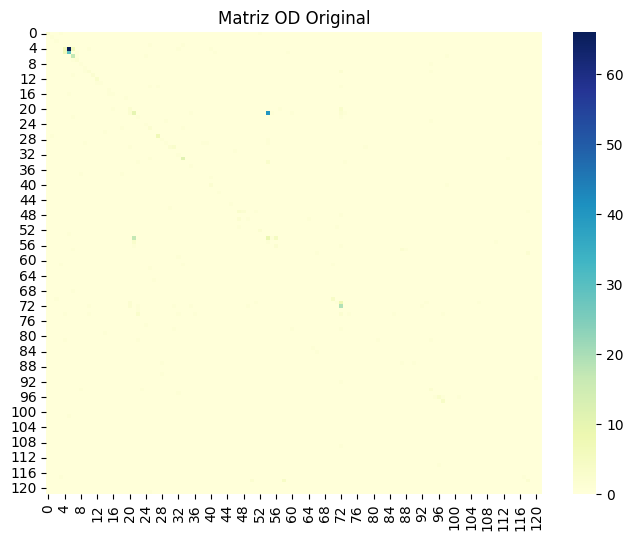

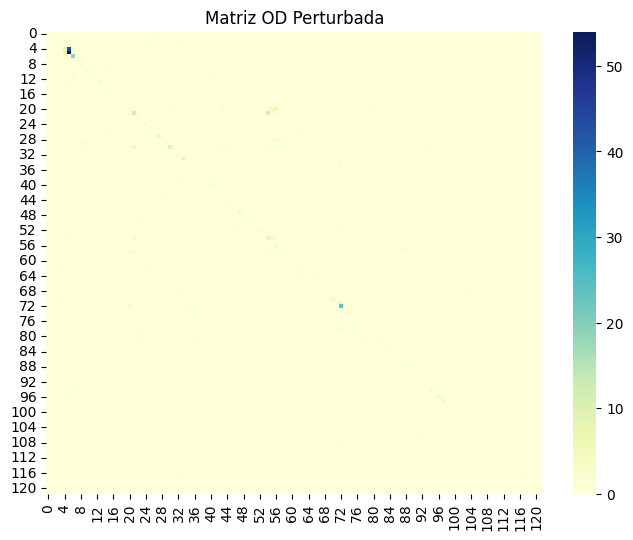

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir a denso solo si no es muy grande
OD_orig_dense = OD_original.todense()
OD_pert_dense = OD_perturbada.todense()

# Heatmap de ejemplo
plt.figure(figsize=(8,6))
sns.heatmap(OD_orig_dense, cmap="YlGnBu", cbar=True)
plt.title("Matriz OD Original")
plt.show()

# Heatmap de ejemplo
plt.figure(figsize=(8,6))
sns.heatmap(OD_pert_dense, cmap="YlGnBu", cbar=True)
plt.title("Matriz OD Perturbada")
plt.show()

 Métricas guardadas en: ../artifacts/anchor/analysis_outputs\metricas_comparacion.csv

TABLA DE VALORES - ANCHOR-BASED PIVOT SAMPLING
 k paso_m MAE MAE_normalizado Error_relativo Frobenius_normalizada
 1 1000 0.027143 0.000411 0.730341 0.583843
 2 1000 0.025135 0.000381 0.636088 0.577551
 3 1000 0.026774 0.000406 0.644592 0.597822
 4 1000 0.027594 0.000418 0.689193 0.621147
 5 1000 0.026911 0.000408 0.650095 0.640220
 1 1500 0.097778 0.001630 0.683433 0.688708
 2 1500 0.100000 0.001695 0.618753 0.712678
 3 1500 0.100556 0.001704 0.593613 0.690124
 4 1500 0.093889 0.001565 0.604285 0.691677
 5 1500 0.097778 0.001657 0.644461 0.627790
 1 2000 0.216263 0.001614 0.675858 0.308489
 2 2000 0.197232 0.001472 0.622877 0.301741
 3 2000 0.198962 0.001474 0.580519 0.327732
 4 2000 0.195502 0.001448 0.645595 0.292377
 5 2000 0.212803 0.001588 0.675139 0.304399
 1 2500 0.632231 0.007710 0.972003 0.648756
 2 2500 0.574380 0.007005 0.788064 0.590808
 3 2500 0.570248 0.006954 0.750095 0.601740
 4 2500

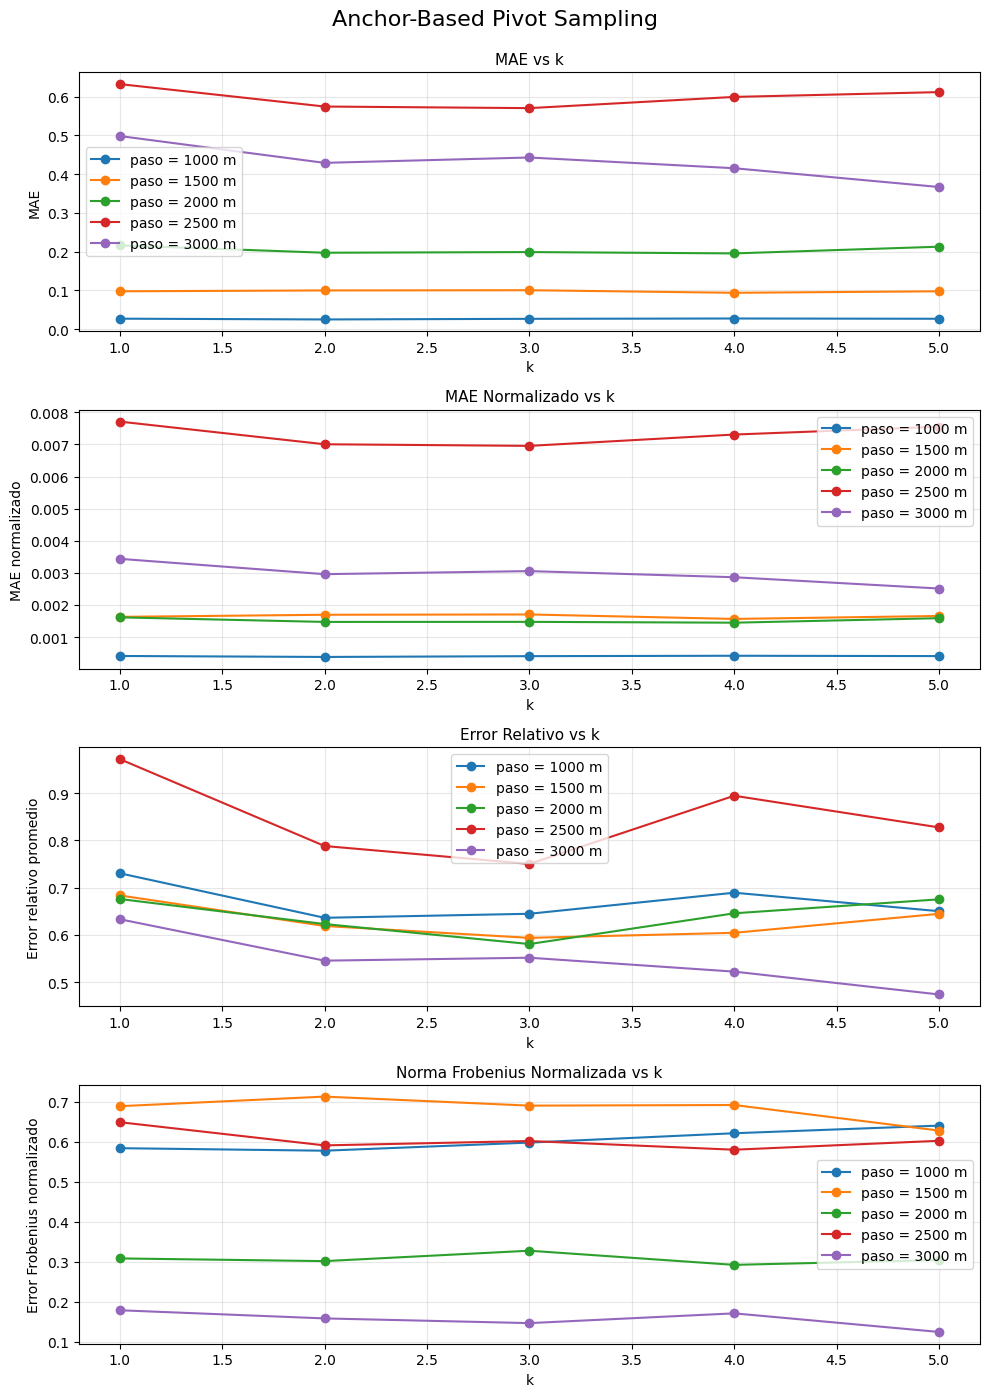

 Tabla HTML guardada en: ../artifacts/anchor/analysis_outputs\tabla_metricas.html


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ================================
# CONFIGURACIÓN
# ================================
carpeta_salida = "../artifacts/anchor/analysis_outputs"

# Buscar todos los pares de archivos originales y perturbados
archivos_original = sorted(glob.glob(os.path.join(carpeta_salida, "OD_original_k*.csv")))
archivos_perturbada = sorted(glob.glob(os.path.join(carpeta_salida, "OD_perturbada_k*.csv")))

# Lista donde guardaremos los resultados de las métricas
resultados = []

# ================================
# 1⃣ CALCULAR MÉTRICAS PARA CADA PAR
# ================================
for orig_file, pert_file in zip(archivos_original, archivos_perturbada):
 # Extraer k y paso_m desde el nombre del archivo
 nombre = os.path.basename(orig_file)
 partes = nombre.replace(".csv", "").split("_")
 k = int(partes[2].replace("k", ""))
 paso_m = int(partes[3].replace("paso", ""))

 # Cargar matrices originales y perturbadas
 original = pd.read_csv(orig_file, header=0).values
 perturbada = pd.read_csv(pert_file, header=0).values

 # Calcular MAE (Error Absoluto Medio)
 mae = np.mean(np.abs(original - perturbada))
 mae_norm = mae / np.max(original) if np.max(original) != 0 else 0

 # Calcular Error Relativo (promedio celda por celda, evitando división por 0)
 mask = original != 0
 if np.any(mask):
 error_relativo = np.mean(np.abs((original[mask] - perturbada[mask]) / original[mask]))
 else:
 error_relativo = 0

 # Calcular Norma de Frobenius (diferencia matricial)
 frobenius = np.linalg.norm(original - perturbada)
 frobenius_norm = frobenius / np.linalg.norm(original) if np.linalg.norm(original) != 0 else 0

 # Guardar resultados
 resultados.append({
 "k": k,
 "paso_m": paso_m,
 "MAE": mae,
 "MAE_normalizado": mae_norm,
 "Error_relativo": error_relativo,
 "Frobenius_normalizada": frobenius_norm
 })

# Verificar si hay resultados
if not resultados:
 raise ValueError(" No se encontraron archivos OD_original_k*.csv y OD_perturbada_k*.csv en la carpeta especificada.")

# Convertir los resultados en un DataFrame ordenado
df_resultados = pd.DataFrame(resultados).sort_values(by=["paso_m", "k"])

# Guardar los resultados en CSV
archivo_resultados = os.path.join(carpeta_salida, "metricas_comparacion.csv")
df_resultados.to_csv(archivo_resultados, index=False)
print(f" Métricas guardadas en: {archivo_resultados}")

# ================================
# 2⃣ MOSTRAR TABLA DE VALORES
# ================================
print("\n" + "="*80)
print("TABLA DE VALORES - ANCHOR-BASED PIVOT SAMPLING")
print("="*80)
print(df_resultados.to_string(index=False))
print("="*80 + "\n")

# ================================
# 3⃣ GRAFICAR LAS MÉTRICAS
# ================================
fig = plt.figure(figsize=(10, 14))
fig.suptitle("Anchor-Based Pivot Sampling", fontsize=16, y=0.995)

# --- Gráfico 1: MAE ---
plt.subplot(4, 1, 1)
for paso in sorted(df_resultados["paso_m"].unique()):
 datos = df_resultados[df_resultados["paso_m"] == paso]
 plt.plot(datos["k"], datos["MAE"], marker='o', label=f"paso = {paso} m")
plt.title("MAE vs k", fontsize=11)
plt.xlabel("k")
plt.ylabel("MAE")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Gráfico 2: MAE Normalizado ---
plt.subplot(4, 1, 2)
for paso in sorted(df_resultados["paso_m"].unique()):
 datos = df_resultados[df_resultados["paso_m"] == paso]
 plt.plot(datos["k"], datos["MAE_normalizado"], marker='o', label=f"paso = {paso} m")
plt.title("MAE Normalizado vs k", fontsize=11)
plt.xlabel("k")
plt.ylabel("MAE normalizado")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Gráfico 3: Error Relativo ---
plt.subplot(4, 1, 3)
for paso in sorted(df_resultados["paso_m"].unique()):
 datos = df_resultados[df_resultados["paso_m"] == paso]
 plt.plot(datos["k"], datos["Error_relativo"], marker='o', label=f"paso = {paso} m")
plt.title("Error Relativo vs k", fontsize=11)
plt.xlabel("k")
plt.ylabel("Error relativo promedio")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Gráfico 4: Norma de Frobenius ---
plt.subplot(4, 1, 4)
for paso in sorted(df_resultados["paso_m"].unique()):
 datos = df_resultados[df_resultados["paso_m"] == paso]
 plt.plot(datos["k"], datos["Frobenius_normalizada"], marker='o', label=f"paso = {paso} m")
plt.title("Norma Frobenius Normalizada vs k", fontsize=11)
plt.xlabel("k")
plt.ylabel("Error Frobenius normalizado")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida, "graficas_metricas.png"), dpi=300, bbox_inches='tight')
print(f" Gráficas guardadas en: {os.path.join(carpeta_salida, 'graficas_metricas.png')}")
plt.show()

# ================================
# 4⃣ CREAR TABLA FORMATEADA EN HTML (OPCIONAL)
# ================================
tabla_html = df_resultados.to_html(index=False, float_format=lambda x: f'{x:.6f}')
archivo_tabla = os.path.join(carpeta_salida, "tabla_metricas.html")
with open(archivo_tabla, 'w') as f:
 f.write(f"<h2>Anchor-Based Pivot Sampling - Tabla de Métricas</h2>\n{tabla_html}")
print(f" Tabla HTML guardada en: {archivo_tabla}")
